# Task 1: Exploring and Visualizing the Iris Dataset

**Internship:** Data Science & Analytics Internship — DevelopersHub Corporation
**Task:** Task 1 — Exploring and Visualizing a Simple Dataset

## Problem Statement
The goal of this task is to practice the first and most important step of any data science
project: understanding a dataset before doing anything else with it. We will load the
classic **Iris flower dataset**, inspect its structure, summarize it numerically, and
visualize the relationships between its features using scatter plots, histograms, and box
plots. These visual and statistical summaries help reveal patterns, distributions, and
potential outliers in the data.

In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 1. Dataset Understanding

The Iris dataset contains 150 samples of iris flowers from three species
(*setosa*, *versicolor*, *virginica*). For each flower, four measurements are recorded:
sepal length, sepal width, petal length, and petal width (all in centimetres).

In [2]:
# Load the dataset
df = pd.read_csv("iris.csv")
print("Shape of dataset:", df.shape)
print("\nColumns:", list(df.columns))
df.head()

Shape of dataset: (150, 5)

Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Basic info and summary statistics
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [4]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
# Check class balance and missing values
print("Missing values per column:\n", df.isnull().sum())
print("\nSamples per species:\n", df['species'].value_counts())

Missing values per column:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Samples per species:
 species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 2. Data Cleaning and Preparation

The Iris dataset is already clean (no missing values, consistent types), so no
imputation or correction is required. This confirms the dataset is ready for direct
exploratory analysis.

## 3. Exploratory Data Analysis (EDA)

### 3.1 Scatter Plot — Relationship Between Variables
We look at how petal length and petal width relate to each other, and whether the three
species separate visually based on these two features.

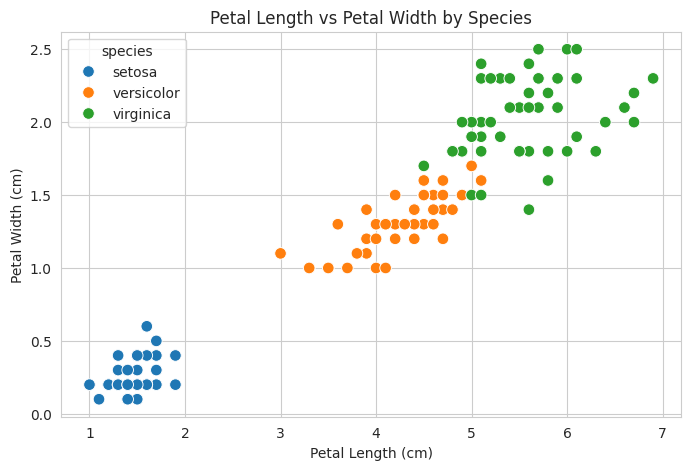

In [6]:
plt.figure()
sns.scatterplot(data=df, x="petal_length", y="petal_width", hue="species", s=70)
plt.title("Petal Length vs Petal Width by Species")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.savefig("images/scatter_petal.png", dpi=120, bbox_inches="tight")
plt.show()

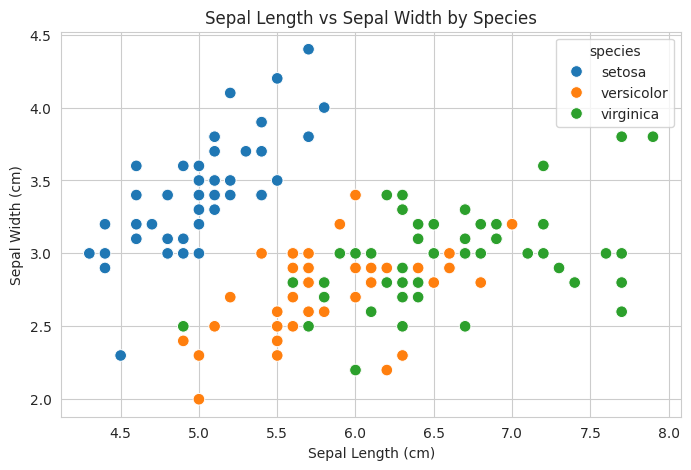

In [7]:
plt.figure()
sns.scatterplot(data=df, x="sepal_length", y="sepal_width", hue="species", s=70)
plt.title("Sepal Length vs Sepal Width by Species")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.savefig("images/scatter_sepal.png", dpi=120, bbox_inches="tight")
plt.show()

**Observation:** *Setosa* is clearly separable from the other two species on petal
measurements alone. *Versicolor* and *virginica* overlap somewhat on sepal measurements but
separate much more cleanly on petal length/width.

### 3.2 Histograms — Data Distribution

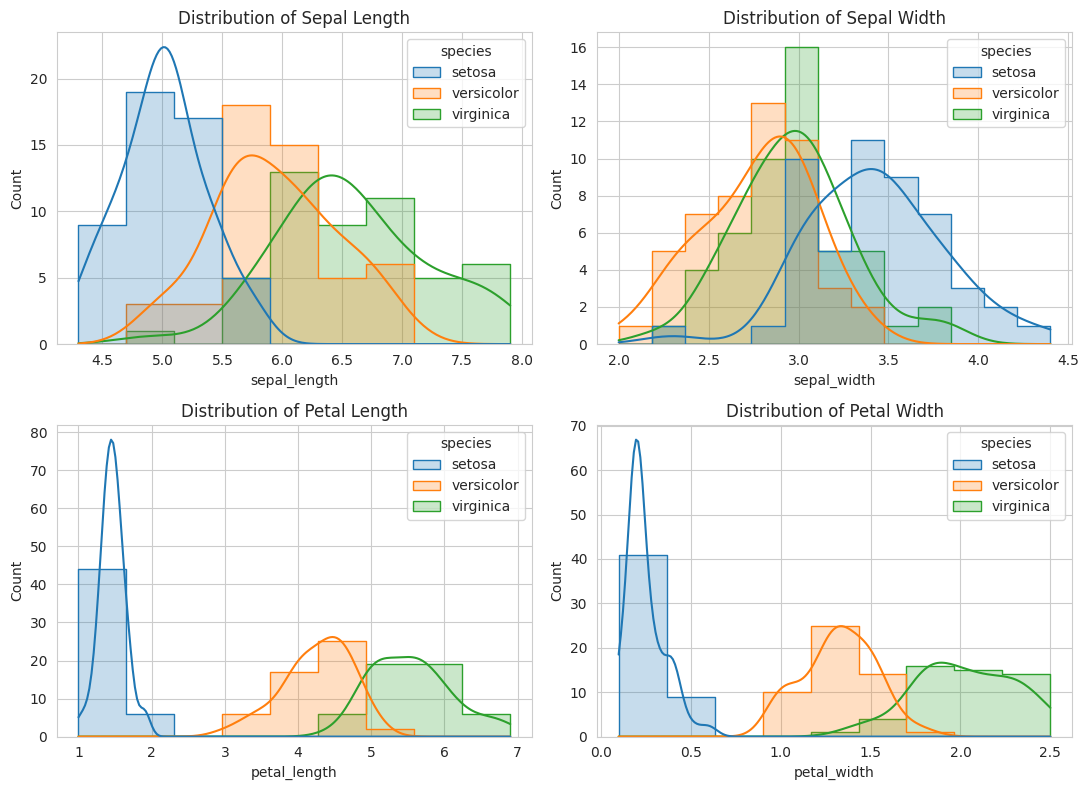

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
for ax, feature in zip(axes.flatten(), features):
    sns.histplot(data=df, x=feature, hue="species", kde=True, ax=ax, element="step")
    ax.set_title(f"Distribution of {feature.replace('_', ' ').title()}")
plt.tight_layout()
plt.savefig("images/histograms.png", dpi=120, bbox_inches="tight")
plt.show()

**Observation:** Petal length and petal width show clearly multi-modal distributions —
this is the visual signature of the three species being mixed together in the full dataset.
Sepal width is closest to a single, roughly normal distribution.

### 3.3 Box Plots — Outliers and Spread

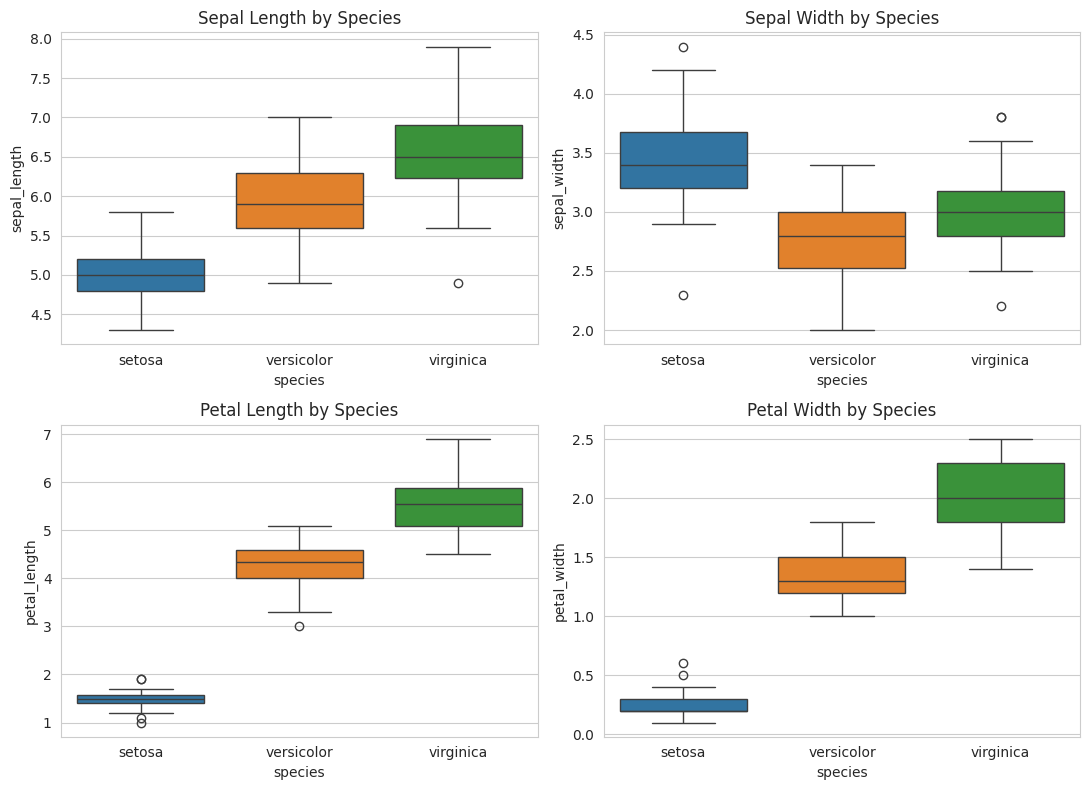

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(data=df, x="species", y=feature, ax=ax, hue="species", legend=False)
    ax.set_title(f"{feature.replace('_', ' ').title()} by Species")
plt.tight_layout()
plt.savefig("images/boxplots.png", dpi=120, bbox_inches="tight")
plt.show()

In [10]:
# Quick outlier check using the IQR method across the whole dataset
for feature in features:
    q1, q3 = df[feature].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = df[(df[feature] < lower) | (df[feature] > upper)]
    print(f"{feature}: {len(outliers)} outlier(s) detected (IQR method)")

sepal_length: 0 outlier(s) detected (IQR method)
sepal_width: 4 outlier(s) detected (IQR method)
petal_length: 0 outlier(s) detected (IQR method)
petal_width: 0 outlier(s) detected (IQR method)


**Observation:** *Setosa* has the smallest spread for petal measurements, with a couple of
mild outliers in sepal width. Overall the dataset has very few outliers — consistent with
it being a small, carefully curated reference dataset rather than messy real-world data.

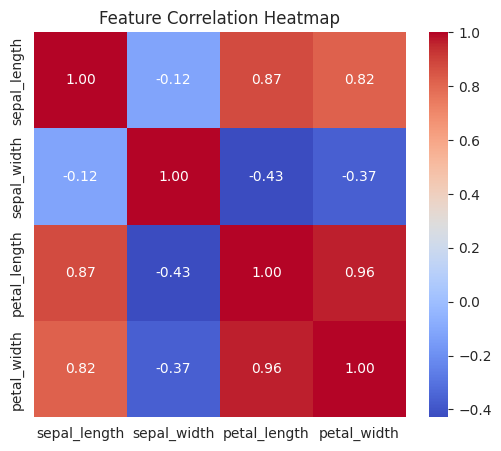

In [11]:
# Correlation heatmap as a bonus summary view
plt.figure(figsize=(6, 5))
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.savefig("images/correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Conclusion

- The Iris dataset is small (150 rows, 5 columns), clean, and balanced (50 samples per species).
- Petal length and petal width are the most discriminative features — they separate the three
  species visually far better than the sepal measurements.
- Petal length and petal width are strongly correlated with each other (and with sepal length),
  which suggests that a model would not need all four features to classify species accurately.
- The dataset contains very few outliers, confirming it is well-suited as a teaching/reference
  dataset for practicing EDA and visualization techniques.

**Skills practiced:** data loading & inspection with pandas, statistical summarization,
and visualization with matplotlib/seaborn (scatter plots, histograms, box plots, heatmaps).